# Data Preparation Pipeline

In this notebook, we document the data preparation work for our phishing URL detection project.

We use this notebook to:
- inspect and clean the raw dataset,
- confirm that the dataset contains raw URL strings and binary labels,
- remove duplicate URLs before splitting,
- create stratified train, validation, and test splits,
- extract handcrafted URL features,
- scale features without data leakage,
- prepare report-ready EDA tables and figures,
- create balanced and imbalanced evaluation test sets,
- prepare a SMOTE-balanced training feature file for classical ML.

The goal is to produce clean, reproducible data files that the rest of the team can use for modeling and evaluation.


# 1. Dataset Setup and Audit

## 1.1 Dataset Source

We use the Mendeley 2026 phishing URL dataset:

**Phishing URL dataset**  
DOI: `10.17632/3jddhy2f6s.1`

The dataset contains raw URLs with binary labels:
- `0` = legitimate URL
- `1` = phishing URL

This dataset is suitable for our project because it provides raw URL strings. We need raw URLs for both handcrafted feature extraction and character-level modeling.

## 1.2 Import Libraries

In [1]:
from pathlib import Path
import os

# Suppress joblib CPU count warning on some Windows machines.
os.environ["LOKY_MAX_CPU_COUNT"] = "1"

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

from urllib.parse import urlparse
from collections import Counter
import math
import re

import matplotlib.pyplot as plt
import seaborn as sns
import joblib


C:\Users\DPQUAI250104\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## 1.3 Configuration

In [2]:
RANDOM_STATE = 42

data_path = Path("../data/raw/mendeley_2026_commoncrawl_phishtank.csv")

processed_dir = Path("../data/processed")
split_dir = Path("../data/splits")
feature_dir = Path("../data/features")
scaled_dir = Path("../data/features_scaled")
models_dir = Path("../models")
report_table_dir = Path("../reports/tables")
figure_dir = Path("../reports/figures")

for folder in [processed_dir, split_dir, feature_dir, scaled_dir, models_dir, report_table_dir, figure_dir]:
    folder.mkdir(parents=True, exist_ok=True)

data_path

WindowsPath('../data/raw/mendeley_2026_commoncrawl_phishtank.csv')

## 1.4 Load Raw Dataset

In [3]:
df = pd.read_csv(data_path, encoding="utf-8")

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

df.head()


Shape: (149726, 2)
Columns: ['URL', 'Label']


,URL,Label
0,https://optus-myaccount.s2-tastewp.com/,1
1,https://www.googleapis.com/auth/drive.file';,0
2,https://wikipedia.org/,0
3,https://www.aol.com/2008-01-23-ask-the-dolans-...,0
4,https://rebrand.ly/uda4njv,1


## 1.5 Quick Data Check

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 149726 entries, 0 to 149725
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   URL     149726 non-null  str  
 1   Label   149726 non-null  int64
dtypes: int64(1), str(1)
memory usage: 12.6 MB


In [5]:
df.sample(5, random_state=RANDOM_STATE)

,URL,Label
125133,https://qcaprod.australiaeast.cloudapp.azure.c...,0
15585,https://usps.bbntnczlrw.top/,1
25447,http://www.theguardian.com/robots.txt,0
143062,https://pub-9ec1967945504971b7ee3cd05fc7a4f9.r...,1
48501,https://ipfs.eth.aragon.network/ipfs/bafkreidd...,1


The dataset has raw URL strings and numeric binary labels, which fits our project setup.

## 1.6 Label Encoding Check

In [6]:
assert df["Label"].isna().sum() == 0, "NaN values found in Label column"

actual_labels = set(df["Label"].unique())

print("Unique labels:", actual_labels)
assert actual_labels == {0, 1}, f"Expected labels {{0, 1}}, got {actual_labels}"

print("0 = Legitimate")
print("1 = Phishing")


Unique labels: {np.int64(0), np.int64(1)}
0 = Legitimate
1 = Phishing


## 1.7 Missing Values

In [7]:
missing_values = df.isna().sum()

print(missing_values)

assert missing_values["URL"] == 0, "NaN values found in URL column."
assert missing_values["Label"] == 0, "NaN values found in Label column."


URL      0
Label    0
dtype: int64


## 1.8 Empty URL Check

In [8]:
# Empty strings are not counted as NaN, so we check them separately.
empty_urls = (df["URL"].astype(str).str.strip() == "").sum()

print("Empty URL strings:", empty_urls)
assert empty_urls == 0, "Empty URL strings found."


Empty URL strings: 0


No missing values or empty URL strings were found, so no rows need to be removed for missing data.

## 1.9 URL Length Sanity Check

In [9]:
url_lengths = df["URL"].str.len()

print(url_lengths.describe().round(1))
print(f"URLs > 200 chars: {(url_lengths > 200).sum()} ({(url_lengths > 200).mean() * 100:.1f}%)")
print(f"URLs > 500 chars: {(url_lengths > 500).sum()}")


count    149726.0
mean         72.0
std         129.1
min          11.0
25%          34.0
50%          50.0
75%          83.0
max       25523.0
Name: URL, dtype: float64
URLs > 200 chars: 4950 (3.3%)
URLs > 500 chars: 1052


This check helps us understand URL length patterns and gives the team evidence for choosing a maximum character sequence length later in the deep model.

## 1.10 Label Distribution


In [10]:
df["Label"].value_counts().sort_index()

Label
0    94919
1    54807
Name: count, dtype: int64

In [11]:
df["Label"].value_counts(normalize=True).sort_index().round(4)

Label
0    0.634
1    0.366
Name: proportion, dtype: float64

The dataset is imbalanced, but it still has both classes. Later, we use stratified splitting so the train, validation, and test sets keep similar class proportions.

## 1.11 Duplicate URL Check


In [12]:
# Strip whitespace before checking duplicates.
df["URL"] = df["URL"].astype(str).str.strip()

df["URL"].duplicated().sum()


np.int64(19950)

Duplicate URL rows were found. We remove them before splitting so the same URL does not appear in both training and test data.

## 1.12 Conflicting Label Check


In [13]:
# Check if the same URL appears with more than one label.
conflicting_count = df.groupby("URL")["Label"].nunique().gt(1).sum()

print("URLs with conflicting labels:", conflicting_count)
assert conflicting_count == 0, "Conflicting labels found. Review before continuing."


URLs with conflicting labels: 0


No conflicting labels were found. This means the same URL is not labeled as both legitimate and phishing.

## 1.13 Remove Duplicate URLs


In [14]:
# Remove duplicate URLs before splitting and reset the index.
df_clean = df.drop_duplicates(subset="URL").reset_index(drop=True).copy()

print("Original shape:", df.shape)
print("Clean shape:", df_clean.shape)
print("Removed rows:", len(df) - len(df_clean))

assert df_clean["URL"].duplicated().sum() == 0


Original shape: (149726, 2)
Clean shape: (129776, 2)
Removed rows: 19950


After removing duplicate URLs, the dataset now has 129,776 unique URL records.

## 1.14 Label Distribution After Cleaning


In [15]:
df_clean["Label"].value_counts().sort_index()

Label
0    74972
1    54804
Name: count, dtype: int64

In [16]:
df_clean["Label"].value_counts(normalize=True).sort_index().round(4)

Label
0    0.5777
1    0.4223
Name: proportion, dtype: float64

After duplicate removal, the cleaned dataset still contains both classes. The class ratio changed because many duplicate rows were from the legitimate class.

## 1.15 Save Clean Dataset


In [17]:
clean_path = processed_dir / "clean_urls.csv"
df_clean.to_csv(clean_path, index=False)

print("Saved to:", clean_path)
print("Final shape:", df_clean.shape)


Saved to: ..\data\processed\clean_urls.csv
Final shape: (129776, 2)


## 1.16 Dataset Audit Summary


In [18]:
print("Raw rows:", len(df))
print("Clean rows:", len(df_clean))
print("Removed duplicate rows:", len(df) - len(df_clean))

print("\nClean label counts:")
print(df_clean["Label"].value_counts().sort_index())

print("\nClean label ratios:")
print(df_clean["Label"].value_counts(normalize=True).sort_index().round(4))


Raw rows: 149726
Clean rows: 129776
Removed duplicate rows: 19950

Clean label counts:
Label
0    74972
1    54804
Name: count, dtype: int64

Clean label ratios:
Label
0    0.5777
1    0.4223
Name: proportion, dtype: float64


The raw dataset contained 149,726 rows. After checking missing values, empty strings, duplicate URLs, and conflicting labels, we removed duplicate URL rows and kept 129,776 unique URLs.

The cleaned dataset contains 74,972 legitimate URLs and 54,804 phishing URLs. This gives us a usable binary dataset for the next stage.


# 2. Train / Validation / Test Split

## 2.1 Split Configuration

In [19]:
train_size = 0.70
val_size = 0.15
test_size = 0.15


## 2.2 Create Stratified Splits

In [20]:
# First split: 70% train and 30% temporary data.
train_df, temp_df = train_test_split(
    df_clean,
    test_size=1 - train_size,
    stratify=df_clean["Label"],
    random_state=RANDOM_STATE
)


In [21]:
# Second split: split the remaining 30% equally into validation and test.
val_df, test_df = train_test_split(
    temp_df,
    test_size=test_size / (val_size + test_size),
    stratify=temp_df["Label"],
    random_state=RANDOM_STATE
)


In [22]:
# Reset indices after splitting to keep each split clean.
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)


Train shape: (90843, 2)
Validation shape: (19466, 2)
Test shape: (19467, 2)


## 2.3 Check Split Distributions

In [23]:
# Check label counts in each split.
print("Train:")
print(train_df["Label"].value_counts().sort_index())

print("\nValidation:")
print(val_df["Label"].value_counts().sort_index())

print("\nTest:")
print(test_df["Label"].value_counts().sort_index())


Train:
Label
0    52480
1    38363
Name: count, dtype: int64

Validation:
Label
0    11246
1     8220
Name: count, dtype: int64

Test:
Label
0    11246
1     8221
Name: count, dtype: int64


In [24]:
# Check label ratios in each split.
print("Train:")
print(train_df["Label"].value_counts(normalize=True).sort_index().round(4))

print("\nValidation:")
print(val_df["Label"].value_counts(normalize=True).sort_index().round(4))

print("\nTest:")
print(test_df["Label"].value_counts(normalize=True).sort_index().round(4))


Train:
Label
0    0.5777
1    0.4223
Name: proportion, dtype: float64

Validation:
Label
0    0.5777
1    0.4223
Name: proportion, dtype: float64

Test:
Label
0    0.5777
1    0.4223
Name: proportion, dtype: float64


The class ratios are the same across train, validation, and test sets. This confirms that stratified splitting worked as expected.

## 2.4 Save Split Files

In [25]:
# Save the split datasets for modeling and feature engineering.
train_df.to_csv(split_dir / "train.csv", index=False)
val_df.to_csv(split_dir / "val.csv", index=False)
test_df.to_csv(split_dir / "test.csv", index=False)

print("Saved train.csv:", train_df.shape)
print("Saved val.csv:", val_df.shape)
print("Saved test.csv:", test_df.shape)


Saved train.csv: (90843, 2)
Saved val.csv: (19466, 2)
Saved test.csv: (19467, 2)


## 2.5 Split Summary Table

In [26]:
split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "rows": [len(train_df), len(val_df), len(test_df)],
    "legitimate_count": [
        (train_df["Label"] == 0).sum(),
        (val_df["Label"] == 0).sum(),
        (test_df["Label"] == 0).sum()
    ],
    "phishing_count": [
        (train_df["Label"] == 1).sum(),
        (val_df["Label"] == 1).sum(),
        (test_df["Label"] == 1).sum()
    ],
    "phishing_ratio": [
        round((train_df["Label"] == 1).mean(), 4),
        round((val_df["Label"] == 1).mean(), 4),
        round((test_df["Label"] == 1).mean(), 4)
    ]
})

split_summary


,split,rows,legitimate_count,phishing_count,phishing_ratio
0,train,90843,52480,38363,0.4223
1,validation,19466,11246,8220,0.4223
2,test,19467,11246,8221,0.4223


In [27]:
split_summary.to_csv(report_table_dir / "split_summary.csv", index=False)

print("Saved split_summary.csv")


Saved split_summary.csv


# 3. Feature Engineering

## 3.1 Handcrafted Feature Set

We extracted 23 handcrafted URL features from the raw URL string.

| Feature group | Features |
|---|---|
| Length-based | `url_length`, `hostname_length`, `path_length`, `query_length` |
| Character counts | `num_dots`, `num_hyphens`, `num_underscores`, `num_slashes`, `num_at_symbol`, `num_question_marks`, `num_equals`, `num_ampersand`, `num_percent`, `num_digits` |
| Ratios / complexity | `digit_ratio`, `shannon_entropy` |
| URL structure | `has_https`, `has_ip_address`, `subdomain_depth`, `path_depth`, `hostname_has_hyphen`, `tld_in_path` |
| Keyword signal | `suspicious_keyword_count` |

## 3.2 Helper Function: Shannon Entropy

In [28]:
def shannon_entropy(text):
    if not text:
        return 0.0

    counts = Counter(text)
    length = len(text)

    entropy = 0.0
    for count in counts.values():
        p = count / length
        entropy -= p * math.log2(p)

    return entropy


We use Shannon entropy to measure how random or complex a URL string looks. Higher entropy does not always mean phishing, but it can be useful when combined with other URL features.

In [29]:
# Quick check with one URL from the training split.
sample_url = train_df["URL"].iloc[0]

print(sample_url)
print("Entropy:", round(shannon_entropy(sample_url), 4))


https://connect.facebook.net/robots.txt
Entropy: 3.7717


## 3.3 URL Feature Extractor

In [30]:
suspicious_words = [
    "login", "secure", "account", "update", "verify",
    "bank", "paypal", "ebay", "signin", "password"
]

ip_pattern = re.compile(r"^\d{1,3}(\.\d{1,3}){3}$")

feature_names = [
    "url_length", "hostname_length", "path_length", "query_length",
    "num_dots", "num_hyphens", "num_underscores", "num_slashes",
    "num_at_symbol", "num_question_marks", "num_equals", "num_ampersand",
    "num_percent", "num_digits", "digit_ratio", "has_https",
    "has_ip_address", "subdomain_depth", "path_depth", "hostname_has_hyphen",
    "tld_in_path", "shannon_entropy", "suspicious_keyword_count"
]


In [31]:
def extract_url_features(url):
    try:
        url = str(url).strip()
        url_lower = url.lower()

        # urlparse reads the hostname better when a scheme exists.
        url_for_parse = url if "://" in url else "http://" + url
        parsed = urlparse(url_for_parse)

        # Use hostname instead of netloc because netloc may include a port.
        hostname = parsed.hostname or ""
        path = parsed.path or ""
        query = parsed.query or ""

        url_length = len(url)
        num_digits = sum(char.isdigit() for char in url)
        path_depth = len([part for part in path.split("/") if part])

        return {
            "url_length": url_length,
            "hostname_length": len(hostname),
            "path_length": len(path),
            "query_length": len(query),
            "num_dots": url.count("."),
            "num_hyphens": url.count("-"),
            "num_underscores": url.count("_"),
            "num_slashes": url.count("/"),
            "num_at_symbol": url.count("@"),
            "num_question_marks": url.count("?"),
            "num_equals": url.count("="),
            "num_ampersand": url.count("&"),
            "num_percent": url.count("%"),
            "num_digits": num_digits,
            "digit_ratio": num_digits / url_length if url_length > 0 else 0,
            "has_https": int(url_lower.startswith("https://")),
            "has_ip_address": int(ip_pattern.match(hostname) is not None),
            "subdomain_depth": max(hostname.count(".") - 1, 0),
            "path_depth": path_depth,
            "hostname_has_hyphen": int("-" in hostname),
            "tld_in_path": int(any(tld in path.lower() for tld in [".com", ".net", ".org", ".edu", ".gov"])),
            "shannon_entropy": shannon_entropy(url),
            "suspicious_keyword_count": sum(word in url_lower for word in suspicious_words)
        }

    except Exception:
        # Keep extraction running if one malformed URL appears.
        return {name: 0 for name in feature_names}


In [32]:
# Test the feature extractor on one URL.
sample_features = extract_url_features(sample_url)

sample_features


{'url_length': 39,
 'hostname_length': 20,
 'path_length': 11,
 'query_length': 0,
 'num_dots': 3,
 'num_hyphens': 0,
 'num_underscores': 0,
 'num_slashes': 3,
 'num_at_symbol': 0,
 'num_question_marks': 0,
 'num_equals': 0,
 'num_ampersand': 0,
 'num_percent': 0,
 'num_digits': 0,
 'digit_ratio': 0.0,
 'has_https': 1,
 'has_ip_address': 0,
 'subdomain_depth': 1,
 'path_depth': 1,
 'hostname_has_hyphen': 0,
 'tld_in_path': 0,
 'shannon_entropy': 3.771669848614623,
 'suspicious_keyword_count': 0}

The feature extractor returns one numeric value for each URL feature. This format is suitable for classical machine learning models later.

## 3.4 Extract Features for Each Split

In [33]:
# List comprehension is faster than apply(...).apply(pd.Series) for this task.
train_features = pd.DataFrame([extract_url_features(url) for url in train_df["URL"]])
val_features = pd.DataFrame([extract_url_features(url) for url in val_df["URL"]])
test_features = pd.DataFrame([extract_url_features(url) for url in test_df["URL"]])

print("Train features:", train_features.shape)
print("Validation features:", val_features.shape)
print("Test features:", test_features.shape)


Train features: (90843, 23)
Validation features: (19466, 23)
Test features: (19467, 23)


Each split now has 23 numeric URL features. The number of rows matches the original train, validation, and test splits, so the feature extraction step worked correctly.

## 3.5 Add Labels to Feature Tables

In [34]:
# Add the target label back to each feature table.
train_features["Label"] = train_df["Label"].values
val_features["Label"] = val_df["Label"].values
test_features["Label"] = test_df["Label"].values

train_features.head()


,url_length,hostname_length,path_length,query_length,num_dots,num_hyphens,num_underscores,num_slashes,num_at_symbol,num_question_marks,...,digit_ratio,has_https,has_ip_address,subdomain_depth,path_depth,hostname_has_hyphen,tld_in_path,shannon_entropy,suspicious_keyword_count,Label
0,39,20,11,0,3,0,0,3,0,0,...,0.000000,1,0,1,1,0,0,3.771670,0,0
1,199,14,177,0,3,20,0,8,0,0,...,0.085427,1,0,1,6,0,0,4.598772,0,0
2,37,10,19,0,1,2,0,5,0,0,...,0.216216,1,0,0,2,0,0,4.280682,0,0
3,159,14,71,65,3,4,0,8,0,1,...,0.163522,1,0,1,6,0,0,4.996675,0,0
4,66,10,48,0,3,0,0,5,0,0,...,0.318182,1,0,1,3,0,0,4.215315,0,0


In [35]:
print("Train:", train_features.shape)
print("Validation:", val_features.shape)
print("Test:", test_features.shape)


Train: (90843, 24)
Validation: (19466, 24)
Test: (19467, 24)


The feature tables now contain 23 handcrafted URL features plus the target label. The row counts still match the train, validation, and test splits.

## 3.6 Feature Quality Check

In [36]:
# Stop the notebook if feature extraction created any missing values.
assert train_features.isna().sum().sum() == 0, "NaN values found in train features."
assert val_features.isna().sum().sum() == 0, "NaN values found in validation features."
assert test_features.isna().sum().sum() == 0, "NaN values found in test features."

print("No missing values found in extracted feature tables.")


No missing values found in extracted feature tables.


## 3.7 Save Unscaled Feature Files

In [37]:
# Save unscaled feature tables for modeling.
train_features.to_csv(feature_dir / "train_features.csv", index=False)
val_features.to_csv(feature_dir / "val_features.csv", index=False)
test_features.to_csv(feature_dir / "test_features.csv", index=False)

print("Saved train_features.csv:", train_features.shape)
print("Saved val_features.csv:", val_features.shape)
print("Saved test_features.csv:", test_features.shape)


Saved train_features.csv: (90843, 24)
Saved val_features.csv: (19466, 24)
Saved test_features.csv: (19467, 24)


The unscaled feature files were saved successfully. These files are useful for tree-based models such as Random Forest.

# 4. Feature Scaling

We create a scaled version of the feature tables for models that are sensitive to feature magnitude, such as Logistic Regression.

We use `StandardScaler` as a simple baseline scaler. The scaler is fitted only on the training data, then applied to the validation and test sets to avoid data leakage.

Tree-based models such as Random Forest can use the unscaled feature files saved earlier.


## 4.1 Select Feature Columns

In [38]:
# Keep all columns except the target label.
feature_cols = [col for col in train_features.columns if col != "Label"]

print("Number of feature columns:", len(feature_cols))


Number of feature columns: 23


## 4.2 Initialize Scaler

In [39]:
# Initialize Scaler
scaler = StandardScaler()

## 4.3 Fit Scaler on Training Data

In [40]:
# Fit Scaler on Training Data to avoid data leakage:
train_scaled = train_features.copy()

train_scaled[feature_cols] = scaler.fit_transform(train_features[feature_cols])

train_scaled.head()

,url_length,hostname_length,path_length,query_length,num_dots,num_hyphens,num_underscores,num_slashes,num_at_symbol,num_question_marks,...,digit_ratio,has_https,has_ip_address,subdomain_depth,path_depth,hostname_has_hyphen,tld_in_path,shannon_entropy,suspicious_keyword_count,Label
0,-0.308787,-0.063811,-0.448387,-0.236344,0.364258,-0.539334,-0.235606,-0.691924,-0.105265,-0.500490,...,-0.885157,0.364327,-0.0588,0.053282,-0.490108,-0.548491,-0.099807,-1.388303,-0.210443,0
1,0.948068,-0.507695,3.753342,-0.236344,0.364258,5.988854,-0.235606,1.872242,-0.105265,-0.500490,...,-0.040065,0.364327,-0.0588,0.053282,2.198635,-0.548491,-0.099807,0.393675,-0.210443,0
2,-0.324498,-0.803618,-0.245894,-0.236344,-0.996054,0.113485,-0.235606,0.333743,-0.105265,-0.500490,...,1.253774,0.364327,-0.0588,-1.392003,0.047640,-0.548491,-0.099807,-0.291644,-0.210443,0
3,0.633854,-0.507695,1.070310,0.530328,0.364258,0.766304,-0.235606,1.872242,-0.105265,1.785614,...,0.732493,0.364327,-0.0588,0.053282,2.198635,-0.548491,-0.099807,1.250950,-0.210443,0
4,-0.096693,-0.803618,0.488143,-0.236344,0.364258,-0.539334,-0.235606,0.333743,-0.105265,-0.500490,...,2.262474,0.364327,-0.0588,0.053282,0.585389,-0.548491,-0.099807,-0.432477,-0.210443,0


## 4.4 Transform Validation and Test Data

In [41]:
val_scaled = val_features.copy()
test_scaled = test_features.copy()

val_scaled[feature_cols] = scaler.transform(val_features[feature_cols])
test_scaled[feature_cols] = scaler.transform(test_features[feature_cols])

print("Train scaled:", train_scaled.shape)
print("Validation scaled:", val_scaled.shape)
print("Test scaled:", test_scaled.shape)


Train scaled: (90843, 24)
Validation scaled: (19466, 24)
Test scaled: (19467, 24)


The scaled feature tables keep the same shape as the unscaled feature tables. The scaler was fitted only on the training data, then applied to validation and test data to avoid data leakage.

## 4.5 Save Scaled Feature Files

In [42]:
# Save scaled feature tables for models that need normalized features.
train_scaled.to_csv(scaled_dir / "train_features_scaled.csv", index=False)
val_scaled.to_csv(scaled_dir / "val_features_scaled.csv", index=False)
test_scaled.to_csv(scaled_dir / "test_features_scaled.csv", index=False)

print("Saved train_features_scaled.csv:", train_scaled.shape)
print("Saved val_features_scaled.csv:", val_scaled.shape)
print("Saved test_features_scaled.csv:", test_scaled.shape)


Saved train_features_scaled.csv: (90843, 24)
Saved val_features_scaled.csv: (19466, 24)
Saved test_features_scaled.csv: (19467, 24)


## 4.6 Save Scaler

In [43]:
# Save the fitted scaler so the same scaling can be used later.
scaler_path = models_dir / "standard_scaler.joblib"
joblib.dump(scaler, scaler_path)

print("Saved scaler to:", scaler_path)


Saved scaler to: ..\models\standard_scaler.joblib


Saving the scaler is important for reproducibility. Later, new URLs should be transformed using this fitted scaler, not a newly fitted scaler.

# 5. Report Tables and Basic EDA

## 5.1 Feature Summary by Class

In [44]:
# We use the training set only for this summary.
selected_features = [
    "url_length",
    "hostname_length",
    "path_length",
    "query_length",
    "num_dots",
    "num_hyphens",
    "num_digits",
    "digit_ratio",
    "has_https",
    "has_ip_address",
    "subdomain_depth",
    "path_depth",
    "hostname_has_hyphen",
    "shannon_entropy",
    "suspicious_keyword_count"
]
len(selected_features)

15

In [45]:
# Compute Mean Feature Values by Class
feature_summary = train_features.groupby("Label")[selected_features].mean().T

feature_summary.columns = ["legitimate_mean", "phishing_mean"]

feature_summary.head()

,legitimate_mean,phishing_mean
url_length,87.079783,66.311107
hostname_length,17.054935,26.071267
path_length,33.049066,22.785288
query_length,28.603620,8.319631
num_dots,2.611776,2.262910


In [46]:
# Compare Phishing and Legitimate Means
feature_summary["difference"] = (
    feature_summary["phishing_mean"] - feature_summary["legitimate_mean"]
)

feature_summary = feature_summary.round(3)

feature_summary

,legitimate_mean,phishing_mean,difference
url_length,87.080,66.311,-20.769
hostname_length,17.055,26.071,9.016
path_length,33.049,22.785,-10.264
query_length,28.604,8.320,-20.284
num_dots,2.612,2.263,-0.349
num_hyphens,2.260,0.820,-1.440
num_digits,11.240,7.210,-4.030
digit_ratio,0.092,0.087,-0.005
has_https,0.873,0.896,0.022
has_ip_address,0.000,0.008,0.008


The feature summary shows that some URL patterns differ between legitimate and phishing URLs. For example, phishing URLs have longer hostnames on average and are more likely to contain hyphens in the hostname. However, not all features separate the classes strongly, so the model should learn from multiple features together rather than relying on one signal.

In [47]:
# Save the table for the report.
feature_summary.to_csv(report_table_dir / "feature_summary_by_class.csv")

print("Saved feature_summary_by_class.csv")

Saved feature_summary_by_class.csv


## 5.2 Class Distribution Plot

In [48]:
# Count labels in the cleaned dataset.
class_counts = df_clean["Label"].value_counts().sort_index()
class_counts.index = ["Legitimate", "Phishing"]

class_counts

Legitimate    74972
Phishing      54804
Name: count, dtype: int64

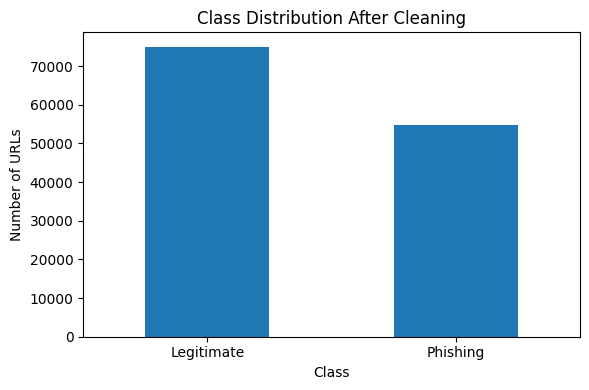

In [49]:
# Plot class distribution after cleaning.
plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar")

plt.title("Class Distribution After Cleaning")
plt.xlabel("Class")
plt.ylabel("Number of URLs")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(figure_dir / "class_distribution.png", dpi=300)
plt.show()

## 5.3 URL Length by Class

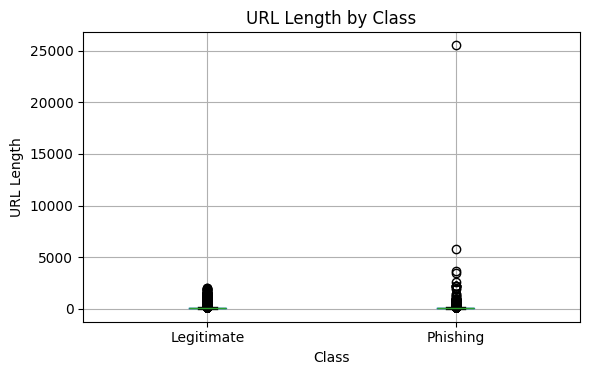

In [50]:
# Compare URL length between legitimate and phishing URLs.
train_features.boxplot(column="url_length", by="Label", figsize=(6, 4))

plt.title("URL Length by Class")
plt.suptitle("")
plt.xlabel("Class")
plt.ylabel("URL Length")

ax = plt.gca()
ax.set_xticklabels(["Legitimate", "Phishing"])

plt.tight_layout()

plt.savefig(figure_dir / "url_length_by_class.png", dpi=300)
plt.show()

## 5.4 URL Length by Class — Capped View

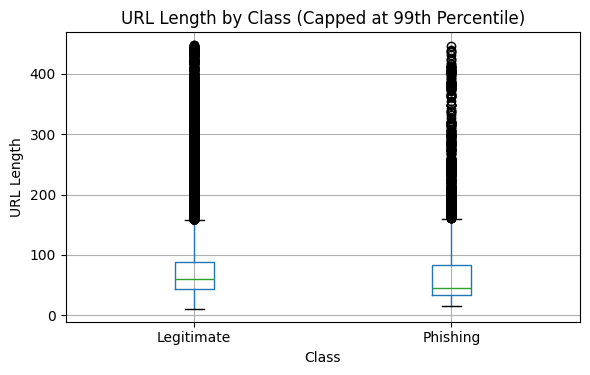

99th percentile cap: 447.58


In [51]:
# Cap the plot at the 99th percentile so extreme outliers do not hide the main pattern.
url_length_cap = train_features["url_length"].quantile(0.99)

url_length_plot = train_features[train_features["url_length"] <= url_length_cap]

url_length_plot.boxplot(column="url_length", by="Label", figsize=(6, 4))

plt.title("URL Length by Class (Capped at 99th Percentile)")
plt.suptitle("")
plt.xlabel("Class")
plt.ylabel("URL Length")

ax = plt.gca()
ax.set_xticklabels(["Legitimate", "Phishing"])

plt.tight_layout()

plt.savefig(figure_dir / "url_length_by_class_capped.png", dpi=300)
plt.show()

print("99th percentile cap:", round(url_length_cap, 2))

The capped URL length plot is easier to interpret than the full boxplot because very long URL outliers no longer dominate the y-axis. In this dataset, legitimate URLs appear to have a slightly higher median URL length, while both classes still contain long URL outliers.

## 5.5 Shannon Entropy by Class

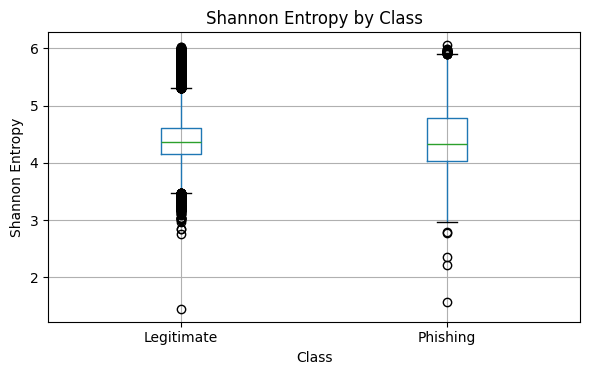

In [52]:
# Compare URL entropy between legitimate and phishing URLs.
train_features.boxplot(column="shannon_entropy", by="Label", figsize=(6, 4))

plt.title("Shannon Entropy by Class")
plt.suptitle("")
plt.xlabel("Class")
plt.ylabel("Shannon Entropy")

ax = plt.gca()
ax.set_xticklabels(["Legitimate", "Phishing"])

plt.tight_layout()

plt.savefig(figure_dir / "shannon_entropy_by_class.png", dpi=300)
plt.show()

The entropy distributions are close, but phishing URLs show a wider spread. This suggests entropy may help the model in combination with other features, but it is not enough as a standalone signal.

## 5.6 Digit Ratio by Class

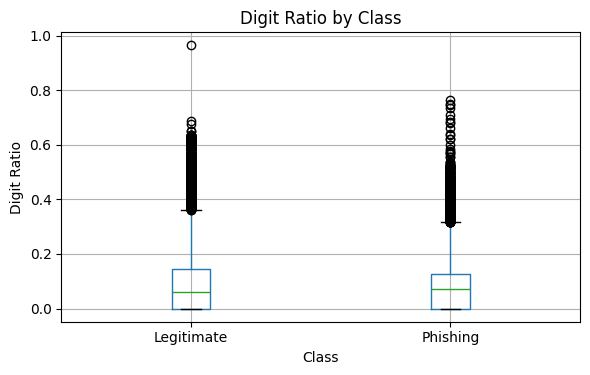

In [53]:
# Compare digit ratio between legitimate and phishing URLs.
train_features.boxplot(column="digit_ratio", by="Label", figsize=(6, 4))

plt.title("Digit Ratio by Class")
plt.suptitle("")
plt.xlabel("Class")
plt.ylabel("Digit Ratio")

ax = plt.gca()
ax.set_xticklabels(["Legitimate", "Phishing"])

plt.tight_layout()

plt.savefig(figure_dir / "digit_ratio_by_class.png", dpi=300)
plt.show()

The digit ratio distributions are fairly close between the two classes. This means digit ratio alone is not a strong separator, but it can still contribute useful information when combined with the other URL features.

## 5.7 Binary Feature Rates by Class

In [54]:
# Compare binary URL features by class.
binary_features = [
    "has_https",
    "has_ip_address",
    "hostname_has_hyphen",
    "tld_in_path"
]

binary_rates = train_features.groupby("Label")[binary_features].mean().T
binary_rates.columns = ["Legitimate", "Phishing"]

binary_rates.round(3)

,Legitimate,Phishing
has_https,0.873,0.896
has_ip_address,0.000,0.008
hostname_has_hyphen,0.102,0.408
tld_in_path,0.014,0.004


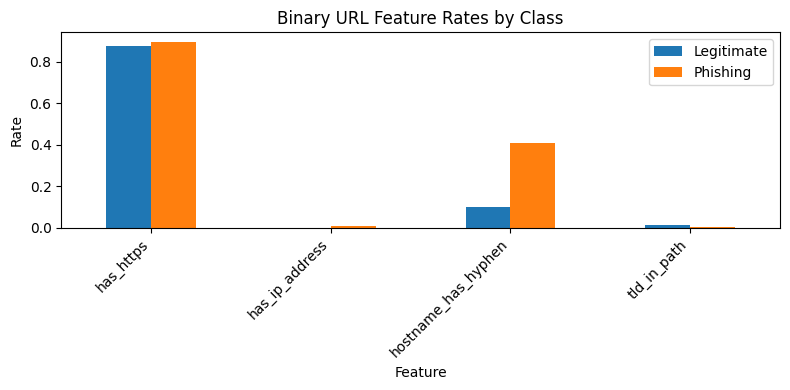

In [55]:
binary_rates.plot(kind="bar", figsize=(8, 4))

plt.title("Binary URL Feature Rates by Class")
plt.xlabel("Feature")
plt.ylabel("Rate")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(figure_dir / "binary_feature_rates_by_class.png", dpi=300)
plt.show()

The binary feature rates show that HTTPS is common in both classes, so HTTPS alone is not enough to identify a phishing URL. The clearest difference here is `hostname_has_hyphen`, which appears much more often in phishing URLs.

In [56]:
# Save binary feature rates for the report.
binary_rates.round(3).to_csv(report_table_dir / "binary_feature_rates_by_class.csv")

print("Saved binary_feature_rates_by_class.csv")

Saved binary_feature_rates_by_class.csv


## 5.8 Top TLDs by Class

In [57]:
# Extract a simple TLD from the hostname for EDA.
def get_tld(url):
    url = str(url).strip()
    url_for_parse = url if "://" in url else "http://" + url
    
    hostname = urlparse(url_for_parse).hostname
    
    if not hostname or "." not in hostname:
        return "unknown"
    
    return hostname.split(".")[-1].lower()

In [58]:
train_tld = train_df.copy()
train_tld["tld"] = train_tld["URL"].apply(get_tld)

train_tld.head()

,URL,Label,tld
0,https://connect.facebook.net/robots.txt,0,net
1,https://ir.netflix.net/investor-news-and-event...,0,net
2,https://elpais.com/acervo/2013-11-29/,0,com
3,https://www.oracle.com/a/ocom/docs/application...,0,com
4,https://www.w3.org/2000/svg%20viewBox=0%200%20...,0,org


In [59]:
top_legitimate_tlds = train_tld[train_tld["Label"] == 0]["tld"].value_counts().head(10)
top_phishing_tlds = train_tld[train_tld["Label"] == 1]["tld"].value_counts().head(10)

print("Top legitimate TLDs:")
print(top_legitimate_tlds)

print("\nTop phishing TLDs:")
print(top_phishing_tlds)

Top legitimate TLDs:
tld
com    31824
net     5946
ru      3472
org     3347
gov      898
edu      844
uk       836
io       673
me       518
de       327
Name: count, dtype: int64

Top phishing TLDs:
tld
com        19922
dev         5206
app         1775
network     1525
io          1266
top         1193
me           547
link         503
org          471
cn           443
Name: count, dtype: int64


The top TLDs differ between the two classes. Both classes use common TLDs like `.com`, but phishing URLs show more frequent use of TLDs such as `.dev`, `.app`, `.top`, and `.link`. This is only an exploratory pattern, not a standalone decision rule.

In [60]:
# Save top TLD tables for the report.
top_legitimate_tlds.to_csv(report_table_dir / "top_legitimate_tlds.csv")
top_phishing_tlds.to_csv(report_table_dir / "top_phishing_tlds.csv")

print("Saved top_legitimate_tlds.csv")
print("Saved top_phishing_tlds.csv")

Saved top_legitimate_tlds.csv
Saved top_phishing_tlds.csv


## 5.9 Top Phishing TLD Plot

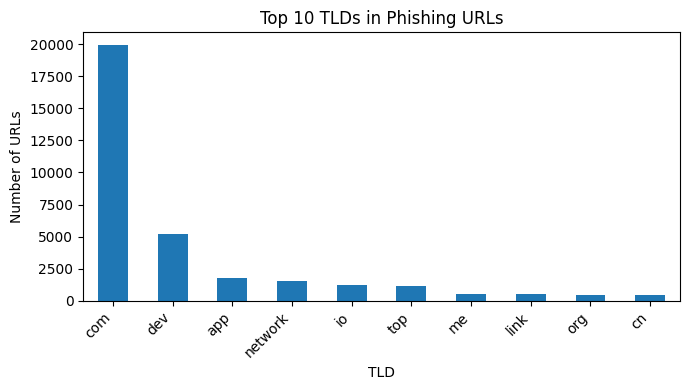

In [61]:
# Plot the top phishing TLDs.
top_phishing_tlds.plot(kind="bar", figsize=(7, 4))

plt.title("Top 10 TLDs in Phishing URLs")
plt.xlabel("TLD")
plt.ylabel("Number of URLs")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(figure_dir / "top_phishing_tlds.png", dpi=300)
plt.show()

The phishing URLs are mostly under `.com`, but several other TLDs such as `.dev`, `.app`, `.network`, `.io`, and `.top` also appear frequently. We should treat this as an exploratory pattern, not as a rule, because legitimate sites can also use these TLDs.

## 5.10 Top Legitimate TLD Plot

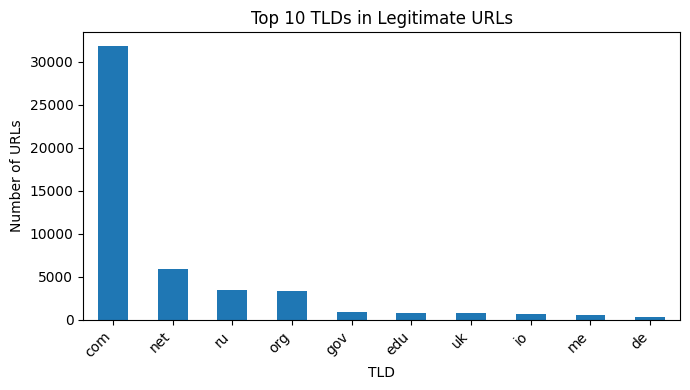

In [62]:
# Plot the top legitimate TLDs.
top_legitimate_tlds.plot(kind="bar", figsize=(7, 4))

plt.title("Top 10 TLDs in Legitimate URLs")
plt.xlabel("TLD")
plt.ylabel("Number of URLs")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(figure_dir / "top_legitimate_tlds.png", dpi=300)
plt.show()

The legitimate URLs are also dominated by `.com`, with `.net`, `.ru`, and `.org` appearing often. Comparing this with the phishing TLD plot helps show that TLD alone is not enough for classification, but it can still provide useful context.

## 5.11 Feature Correlation Heatmap

In [63]:
# Use selected numeric features to keep the heatmap readable.
corr_features = [
    "url_length",
    "hostname_length",
    "path_length",
    "query_length",
    "num_dots",
    "num_hyphens",
    "num_digits",
    "digit_ratio",
    "subdomain_depth",
    "path_depth",
    "shannon_entropy",
    "suspicious_keyword_count",
    "Label"
]

corr_matrix = train_features[corr_features].corr()

corr_matrix.round(2)

,url_length,hostname_length,path_length,query_length,num_dots,num_hyphens,num_digits,digit_ratio,subdomain_depth,path_depth,shannon_entropy,suspicious_keyword_count,Label
url_length,1.00,0.03,0.29,0.66,0.40,0.27,0.84,0.20,0.07,0.21,0.41,0.28,-0.08
hostname_length,0.03,1.00,-0.15,-0.05,0.25,-0.01,0.04,0.15,0.56,-0.22,0.17,-0.02,0.33
path_length,0.29,-0.15,1.00,-0.01,0.16,0.50,0.18,0.09,0.00,0.68,0.39,0.03,-0.13
query_length,0.66,-0.05,-0.01,1.00,0.46,0.16,0.75,0.22,0.02,0.04,0.39,0.41,-0.12
num_dots,0.40,0.25,0.16,0.46,1.00,0.14,0.41,0.21,0.52,0.18,0.33,0.34,-0.12
num_hyphens,0.27,-0.01,0.50,0.16,0.14,1.00,0.16,0.02,0.06,0.27,0.21,0.09,-0.23
num_digits,0.84,0.04,0.18,0.75,0.41,0.16,1.00,0.46,0.05,0.14,0.33,0.30,-0.07
digit_ratio,0.20,0.15,0.09,0.22,0.21,0.02,0.46,1.00,0.05,0.11,0.39,0.08,-0.02
subdomain_depth,0.07,0.56,0.00,0.02,0.52,0.06,0.05,0.05,1.00,0.00,0.16,0.02,0.01
path_depth,0.21,-0.22,0.68,0.04,0.18,0.27,0.14,0.11,0.00,1.00,0.38,0.06,-0.34


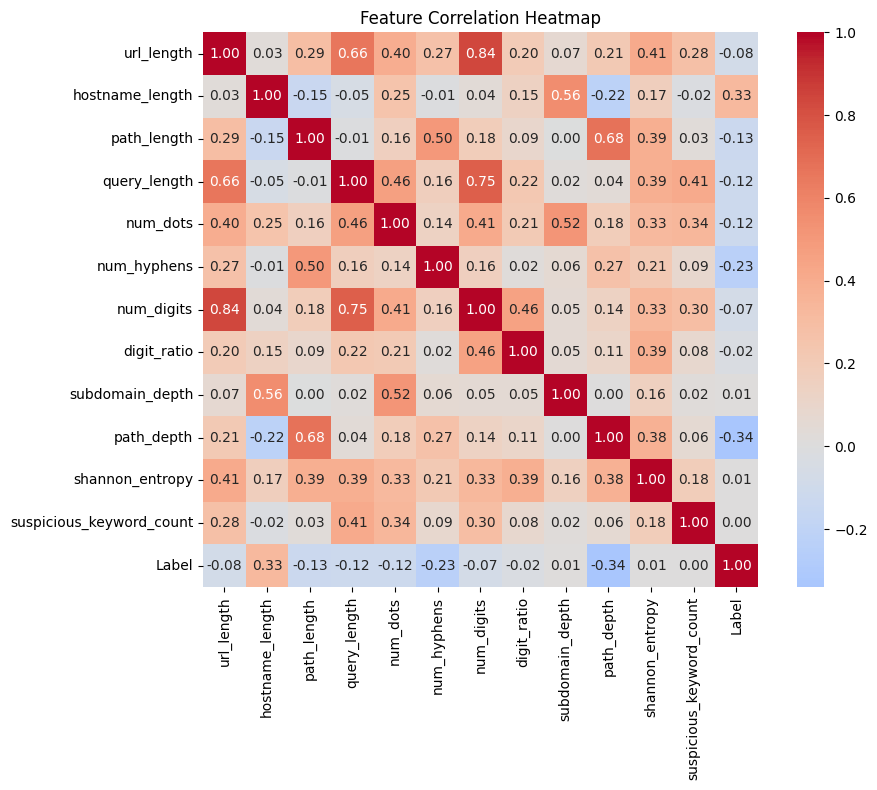

In [64]:
# Plot a readable correlation heatmap with values.
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()

plt.savefig(figure_dir / "feature_correlation_heatmap.png", dpi=300)
plt.show()


The correlation heatmap shows that no single handcrafted feature fully explains the label. Some features have clearer relationships with the target, such as `hostname_length` and `path_depth`, but the model should combine multiple URL signals rather than depend on one feature.

In [65]:
# Save the correlation matrix for the report.
corr_matrix.round(3).to_csv(report_table_dir / "feature_correlation_matrix.csv")

print("Saved feature_correlation_matrix.csv")

Saved feature_correlation_matrix.csv


# 6. Balanced and Imbalanced Test Sets

## 6.1 Create Balanced Test Set

In [66]:
# Separate the two classes from the test set.
test_legitimate = test_df[test_df["Label"] == 0]
test_phishing = test_df[test_df["Label"] == 1]

print("Legitimate test URLs:", len(test_legitimate))
print("Phishing test URLs:", len(test_phishing))

Legitimate test URLs: 11246
Phishing test URLs: 8221


In [67]:
# Use the smaller class size so both classes have equal counts.
n_balanced = min(len(test_legitimate), len(test_phishing))

test_balanced = pd.concat([
    test_legitimate.sample(n=n_balanced, random_state=RANDOM_STATE),
    test_phishing.sample(n=n_balanced, random_state=RANDOM_STATE)
])

test_balanced = test_balanced.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

In [68]:
# Check the final balanced test set.
print("Balanced test shape:", test_balanced.shape)
print(test_balanced["Label"].value_counts().sort_index())
print(test_balanced["Label"].value_counts(normalize=True).sort_index().round(4))

Balanced test shape: (16442, 2)
Label
0    8221
1    8221
Name: count, dtype: int64
Label
0    0.5
1    0.5
Name: proportion, dtype: float64


The balanced test set has equal numbers of legitimate and phishing URLs. We will use it later to evaluate models under a controlled 50/50 class distribution.

## 6.2 Create Imbalanced Test Set

In [69]:
# We create an 80/20 test set to simulate a more realistic setting.
target_phishing_ratio = 0.20

In [70]:
# Keep all legitimate test URLs and sample enough phishing URLs to reach about 80/20.
n_legitimate = len(test_legitimate)
n_phishing_imbalanced = int((target_phishing_ratio / (1 - target_phishing_ratio)) * n_legitimate)

assert n_phishing_imbalanced <= len(test_phishing), (
    f"Not enough phishing URLs ({len(test_phishing)}) "
    f"to reach target ratio {target_phishing_ratio}"
)

print("Legitimate URLs kept:", n_legitimate)
print("Phishing URLs sampled:", n_phishing_imbalanced)


Legitimate URLs kept: 11246
Phishing URLs sampled: 2811


In [71]:
test_imbalanced = pd.concat([
    test_legitimate,
    test_phishing.sample(n=n_phishing_imbalanced, random_state=RANDOM_STATE)
])

test_imbalanced = test_imbalanced.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

In [72]:
# Check the final imbalanced test set.
print("Imbalanced test shape:", test_imbalanced.shape)
print(test_imbalanced["Label"].value_counts().sort_index())
print(test_imbalanced["Label"].value_counts(normalize=True).sort_index().round(4))

Imbalanced test shape: (14057, 2)
Label
0    11246
1     2811
Name: count, dtype: int64
Label
0    0.8
1    0.2
Name: proportion, dtype: float64


The imbalanced test set keeps all legitimate test URLs and samples phishing URLs to create an 80/20 class ratio. This gives us a more realistic evaluation setting where legitimate URLs are more common than phishing URLs.

## 6.3 Save Balanced and Imbalanced Test Sets

In [73]:
# Save the extra test sets for later model evaluation.
test_balanced.to_csv(split_dir / "test_balanced.csv", index=False)
test_imbalanced.to_csv(split_dir / "test_imbalanced_80_20.csv", index=False)

print("Saved test_balanced.csv:", test_balanced.shape)
print("Saved test_imbalanced_80_20.csv:", test_imbalanced.shape)

Saved test_balanced.csv: (16442, 2)
Saved test_imbalanced_80_20.csv: (14057, 2)


The balanced and imbalanced test sets were saved successfully. These files will be used later for model evaluation only, not for training.

## 6.4 Extract Features for Evaluation Test Sets

In [74]:
# Extract features for the balanced and imbalanced test sets.
balanced_test_features = pd.DataFrame([
    extract_url_features(url) for url in test_balanced["URL"]
])

imbalanced_test_features = pd.DataFrame([
    extract_url_features(url) for url in test_imbalanced["URL"]
])

print("Balanced test features:", balanced_test_features.shape)
print("Imbalanced test features:", imbalanced_test_features.shape)

Balanced test features: (16442, 23)
Imbalanced test features: (14057, 23)


In [75]:
# Add labels back to the feature tables.
balanced_test_features["Label"] = test_balanced["Label"].values
imbalanced_test_features["Label"] = test_imbalanced["Label"].values

print("Balanced test features:", balanced_test_features.shape)
print("Imbalanced test features:", imbalanced_test_features.shape)

Balanced test features: (16442, 24)
Imbalanced test features: (14057, 24)


We extracted the same 23 handcrafted features for the balanced and imbalanced test sets. These files will support later classical model evaluation under both 50/50 and 80/20 class distributions.

## 6.5 Save Evaluation Feature Files

In [76]:
# Save unscaled features for the extra evaluation test sets.
balanced_test_features.to_csv(feature_dir / "test_balanced_features.csv", index=False)
imbalanced_test_features.to_csv(feature_dir / "test_imbalanced_80_20_features.csv", index=False)

print("Saved test_balanced_features.csv:", balanced_test_features.shape)
print("Saved test_imbalanced_80_20_features.csv:", imbalanced_test_features.shape)

Saved test_balanced_features.csv: (16442, 24)
Saved test_imbalanced_80_20_features.csv: (14057, 24)


## 6.6 Scale Evaluation Feature Files

In [77]:
# Scale the extra evaluation feature sets using the training scaler.
balanced_test_scaled = balanced_test_features.copy()
imbalanced_test_scaled = imbalanced_test_features.copy()

balanced_test_scaled[feature_cols] = scaler.transform(balanced_test_features[feature_cols])
imbalanced_test_scaled[feature_cols] = scaler.transform(imbalanced_test_features[feature_cols])

print("Balanced test scaled:", balanced_test_scaled.shape)
print("Imbalanced test scaled:", imbalanced_test_scaled.shape)

Balanced test scaled: (16442, 24)
Imbalanced test scaled: (14057, 24)


In [78]:
# Save scaled features for the extra evaluation test sets.
balanced_test_scaled.to_csv(scaled_dir / "test_balanced_features_scaled.csv", index=False)
imbalanced_test_scaled.to_csv(scaled_dir / "test_imbalanced_80_20_features_scaled.csv", index=False)

print("Saved test_balanced_features_scaled.csv:", balanced_test_scaled.shape)
print("Saved test_imbalanced_80_20_features_scaled.csv:", imbalanced_test_scaled.shape)

Saved test_balanced_features_scaled.csv: (16442, 24)
Saved test_imbalanced_80_20_features_scaled.csv: (14057, 24)


The balanced and imbalanced evaluation feature files were saved in both unscaled and scaled formats. The scaled versions use the same scaler fitted on the original training set, so no test-set information is used during preprocessing.

# 7. SMOTE Training Set for Classical ML

We create an optional SMOTE-balanced training feature set for classical machine learning models.

SMOTE is applied only to the training features. We do not apply it to validation, test, balanced test, or imbalanced test sets.

## 7.1 Prepare Training Features and Labels

In [79]:
feature_cols = [col for col in train_scaled.columns if col != "Label"]

In [80]:
# Use the scaled training features because SMOTE is distance-based.
X_train_scaled = train_scaled[feature_cols]
y_train = train_scaled["Label"]

print("Before SMOTE:")
print(y_train.value_counts().sort_index())

Before SMOTE:
Label
0    52480
1    38363
Name: count, dtype: int64


## 7.2 Apply SMOTE to Training Features

In [81]:
# SMOTE is applied only to the training set.
smote = SMOTE(random_state=RANDOM_STATE)

X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("After SMOTE:")
print(pd.Series(y_train_smote).value_counts().sort_index())


After SMOTE:
Label
0    52480
1    52480
Name: count, dtype: int64


SMOTE balanced only the training feature set. We do not apply SMOTE to validation or test data because those sets should represent real evaluation data.

## 7.3 Save SMOTE Training Features

In [82]:
# Store the SMOTE output as a scaled training feature table.
train_smote_scaled = pd.DataFrame(X_train_smote, columns=feature_cols)
train_smote_scaled["Label"] = y_train_smote

print("SMOTE training shape:", train_smote_scaled.shape)
print(train_smote_scaled["Label"].value_counts().sort_index())


SMOTE training shape: (104960, 24)
Label
0    52480
1    52480
Name: count, dtype: int64


In [83]:
# Save SMOTE-balanced training features for classical ML models.
train_smote_scaled.to_csv(scaled_dir / "train_features_smote_scaled.csv", index=False)

print("Saved train_features_smote_scaled.csv:", train_smote_scaled.shape)

Saved train_features_smote_scaled.csv: (104960, 24)


SMOTE balanced only the scaled training feature set. We keep the original train, validation, and test files unchanged. This SMOTE file is optional and should be used only for classical ML models, not for the character-level CNN/RNN.

# 8. Generated Files Summary

In [84]:
generated_files = pd.DataFrame([
    # Cleaned data
    ["data/processed/clean_urls.csv", "Cleaned unique URL dataset"],

    # Main raw URL splits
    ["data/splits/train.csv", "Training split with raw URLs"],
    ["data/splits/val.csv", "Validation split with raw URLs"],
    ["data/splits/test.csv", "Original test split with raw URLs"],

    # Extra evaluation test sets
    ["data/splits/test_balanced.csv", "Balanced 50/50 evaluation test set"],
    ["data/splits/test_imbalanced_80_20.csv", "Imbalanced 80/20 evaluation test set"],

    # Unscaled feature files
    ["data/features/train_features.csv", "Unscaled handcrafted train features"],
    ["data/features/val_features.csv", "Unscaled handcrafted validation features"],
    ["data/features/test_features.csv", "Unscaled handcrafted test features"],
    ["data/features/test_balanced_features.csv", "Unscaled balanced test features"],
    ["data/features/test_imbalanced_80_20_features.csv", "Unscaled imbalanced test features"],

    # Scaled feature files
    ["data/features_scaled/train_features_scaled.csv", "Scaled train features"],
    ["data/features_scaled/val_features_scaled.csv", "Scaled validation features"],
    ["data/features_scaled/test_features_scaled.csv", "Scaled test features"],
    ["data/features_scaled/test_balanced_features_scaled.csv", "Scaled balanced test features"],
    ["data/features_scaled/test_imbalanced_80_20_features_scaled.csv", "Scaled imbalanced test features"],
    ["data/features_scaled/train_features_smote_scaled.csv", "SMOTE-balanced scaled train features for classical ML"],

    # Model preprocessing object
    ["models/standard_scaler.joblib", "Scaler fitted on training features only"],

    # Report tables
    ["reports/tables/split_summary.csv", "Split statistics for report"],
    ["reports/tables/feature_summary_by_class.csv", "Mean feature comparison by class"],
    ["reports/tables/binary_feature_rates_by_class.csv", "Binary URL feature rates by class"],
    ["reports/tables/top_legitimate_tlds.csv", "Top TLDs in legitimate training URLs"],
    ["reports/tables/top_phishing_tlds.csv", "Top TLDs in phishing training URLs"],
    ["reports/tables/feature_correlation_matrix.csv", "Correlation matrix for selected features"],
    ["reports/tables/generated_files_summary.csv", "Summary of generated pipeline files"],

    # Report figures
    ["reports/figures/class_distribution.png", "Class distribution after cleaning"],
    ["reports/figures/url_length_by_class.png", "URL length boxplot by class"],
    ["reports/figures/url_length_by_class_capped.png", "Capped URL length boxplot by class"],
    ["reports/figures/shannon_entropy_by_class.png", "Shannon entropy boxplot by class"],
    ["reports/figures/digit_ratio_by_class.png", "Digit ratio boxplot by class"],
    ["reports/figures/binary_feature_rates_by_class.png", "Binary feature rates by class"],
    ["reports/figures/top_phishing_tlds.png", "Top phishing TLDs plot"],
    ["reports/figures/top_legitimate_tlds.png", "Top legitimate TLDs plot"],
    ["reports/figures/feature_correlation_heatmap.png", "Selected feature correlation heatmap"],
], columns=["file", "description"])

generated_files

,file,description
0,data/processed/clean_urls.csv,Cleaned unique URL dataset
1,data/splits/train.csv,Training split with raw URLs
2,data/splits/val.csv,Validation split with raw URLs
3,data/splits/test.csv,Original test split with raw URLs
4,data/splits/test_balanced.csv,Balanced 50/50 evaluation test set
5,data/splits/test_imbalanced_80_20.csv,Imbalanced 80/20 evaluation test set
6,data/features/train_features.csv,Unscaled handcrafted train features
7,data/features/val_features.csv,Unscaled handcrafted validation features
8,data/features/test_features.csv,Unscaled handcrafted test features
9,data/features/test_balanced_features.csv,Unscaled balanced test features


In [85]:
# Save the generated files summary for documentation.
generated_files.to_csv(report_table_dir / "generated_files_summary.csv", index=False)

print("Saved generated_files_summary.csv")
print("Total documented files:", len(generated_files))

Saved generated_files_summary.csv
Total documented files: 34


# 9. Final Pipeline Checks

We run one final check to make sure the saved files are consistent with the current pipeline outputs.

In [86]:
# Load saved files for a quick consistency check.
saved_clean = pd.read_csv(clean_path)

saved_train = pd.read_csv(split_dir / "train.csv")
saved_val = pd.read_csv(split_dir / "val.csv")
saved_test = pd.read_csv(split_dir / "test.csv")

saved_train_features = pd.read_csv(feature_dir / "train_features.csv")
saved_val_features = pd.read_csv(feature_dir / "val_features.csv")
saved_test_features = pd.read_csv(feature_dir / "test_features.csv")

saved_train_scaled = pd.read_csv(scaled_dir / "train_features_scaled.csv")
saved_val_scaled = pd.read_csv(scaled_dir / "val_features_scaled.csv")
saved_test_scaled = pd.read_csv(scaled_dir / "test_features_scaled.csv")

In [87]:
# Make sure saved files are consistent with the current pipeline.
assert saved_clean.shape == df_clean.shape

assert len(saved_train) + len(saved_val) + len(saved_test) == len(df_clean)

assert saved_train_features.shape[0] == len(saved_train)
assert saved_val_features.shape[0] == len(saved_val)
assert saved_test_features.shape[0] == len(saved_test)

assert saved_train_scaled.shape[0] == len(saved_train)
assert saved_val_scaled.shape[0] == len(saved_val)
assert saved_test_scaled.shape[0] == len(saved_test)

print("All saved files match the current pipeline outputs.")

All saved files match the current pipeline outputs.


The saved files are consistent with the cleaned dataset, splits, feature tables, and scaled feature tables.

# 10. Final Summary

In [88]:
print("=" * 50)
print("DATA PREPARATION SUMMARY")
print("=" * 50)

print("\nDataset:")
print("Raw dataset:", df.shape)
print("Clean dataset:", df_clean.shape)

print("\nMain splits:")
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nEvaluation test sets:")
print("Balanced test:", test_balanced.shape)
print("Imbalanced test:", test_imbalanced.shape)

print("\nFeature files:")
print("Train features:", train_features.shape)
print("Validation features:", val_features.shape)
print("Test features:", test_features.shape)
print("Balanced test features:", balanced_test_features.shape)
print("Imbalanced test features:", imbalanced_test_features.shape)

print("\nScaled feature files:")
print("Train scaled:", train_scaled.shape)
print("Validation scaled:", val_scaled.shape)
print("Test scaled:", test_scaled.shape)
print("Balanced test scaled:", balanced_test_scaled.shape)
print("Imbalanced test scaled:", imbalanced_test_scaled.shape)

print("\nSMOTE training set:")
print("SMOTE train scaled:", train_smote_scaled.shape)

print("\nReport outputs:")
print("Generated files documented:", len(generated_files))

DATA PREPARATION SUMMARY

Dataset:
Raw dataset: (149726, 2)
Clean dataset: (129776, 2)

Main splits:
Train: (90843, 2)
Validation: (19466, 2)
Test: (19467, 2)

Evaluation test sets:
Balanced test: (16442, 2)
Imbalanced test: (14057, 2)

Feature files:
Train features: (90843, 24)
Validation features: (19466, 24)
Test features: (19467, 24)
Balanced test features: (16442, 24)
Imbalanced test features: (14057, 24)

Scaled feature files:
Train scaled: (90843, 24)
Validation scaled: (19466, 24)
Test scaled: (19467, 24)
Balanced test scaled: (16442, 24)
Imbalanced test scaled: (14057, 24)

SMOTE training set:
SMOTE train scaled: (104960, 24)

Report outputs:
Generated files documented: 34
